# Task 5 – Analysis of Performance and Control in Different Wind Conditions
## 16 MW Offshore Wind Turbine — Based on Task 2 BEM Design
---
**Sub-tasks covered:**
- **5a** — BEM sweep: 50%–200% nominal wind speed at fixed pitch angles
- **5b** — Operation envelope: 2D contour map of power vs (V₀, θₚ)
- **5c** — Mechanical loads at 200% nominal wind (flapwise/edgewise BM + root stress)
- **5d** — Discussion: adapting blade for onshore 8 MW (half power)

---
⚠️ **How to run:** Execute every cell top-to-bottom in order. Cell 3 file paths must match your machine.

# Cell 1 — Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import glob
print('Imports OK')

Imports OK


# Cell 2 — Design Parameters (same as Task 2)

In [12]:
# ═══════════════════════════════════════════════════════════
# DESIGN PARAMETERS  — keep identical to Task 2
# ═══════════════════════════════════════════════════════════
P_rated  = 16e6       # rated power [W] = 16 MW
V0_nom   = 11.0       # nominal wind speed [m/s]
rho_air  = 1.225      # air density [kg/m³]
B        = 3          # number of blades
TSR      = 8.0        # tip speed ratio
R_design = 120.4      # blade radius [m]
N_ELEMENTS = 19

Omega_nom = TSR * V0_nom / R_design   # nominal angular velocity [rad/s]
RPM_nom   = Omega_nom * 60 / (2 * np.pi)

# ── Task 5 wind range: 50% to 200% of nominal ──
V_MIN = 0.5 * V0_nom   # = 5.5 m/s
V_MAX = 2.0 * V0_nom   # = 22.0 m/s

print(f'Nominal wind : {V0_nom} m/s')
print(f'50%  nominal : {V_MIN} m/s')
print(f'200% nominal : {V_MAX} m/s')
print(f'Nominal RPM  : {RPM_nom:.2f}')
print(f'Rated power  : {P_rated/1e6:.1f} MW')

Nominal wind : 11.0 m/s
50%  nominal : 5.5 m/s
200% nominal : 22.0 m/s
Nominal RPM  : 6.98
Rated power  : 16.0 MW


# Cell 3 — File Paths
⚠️ **Update `BASE_DIR` and `CLD_FOLDER` to match your machine.**

In [13]:
# ⚠ CHANGE THESE to match your folder paths
BASE_DIR   = r'C:\Users\user\Downloads\sustainable energy\coding sustainable'
CLD_FOLDER = r'C:\Users\user\Downloads\sustainable energy\Deisgn coursework\Design shape folder\Airfoil-Coords-CLD\CLD'
REF_GEOM_CSV = os.path.join(BASE_DIR, 'RISO-A1-A18 Profile for 500kW Reference Turbine Blade.csv')

OUT_DIR = os.path.join(BASE_DIR, 'Task5_outputs')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output folder: {OUT_DIR}')

Output folder: C:\Users\user\Downloads\sustainable energy\coding sustainable\Task5_outputs


# Cell 4 — All Function Definitions
Run this cell first — all BEM functions copied from Task 2 Clean.

In [14]:
# ═══════════════════════════════════════════════════════════
# ALL FUNCTIONS  (identical to Task 2 Clean)
# ═══════════════════════════════════════════════════════════

def read_geometry(filepath, verbose=True):
    df = pd.read_csv(filepath)
    df.columns = [c.strip().lower() for c in df.columns]
    r_col    = next(c for c in df.columns if 'radial' in c or ('r' in c and '(m)' in c))
    beta_col = next(c for c in df.columns if 'twist' in c)
    c_col    = next(c for c in df.columns if 'chord' in c)
    r     = df[r_col].to_numpy(float)
    beta  = df[beta_col].to_numpy(float)
    chord = df[c_col].to_numpy(float)
    order = np.argsort(r)
    r, beta, chord = r[order], beta[order], chord[order]
    if verbose:
        print(f'Loaded {len(r)} nodes: r = [{r[0]:.2f}, {r[-1]:.2f}] m')
    return r, beta, chord


def read_polar(filepath):
    try:
        df = pd.read_csv(filepath, sep=r'\t', engine='python', comment='!')
        if df.shape[1] == 1:
            raise ValueError
    except:
        try:
            df = pd.read_csv(filepath, sep=r'\s+', engine='python', comment='!')
        except:
            df = pd.read_csv(filepath, comment='!')
    df.columns = [c.strip().lower() for c in df.columns]
    alpha_col = next((c for c in df.columns if 'alpha' in c or 'degree' in c), df.columns[0])
    cl_col    = next((c for c in df.columns if c == 'cl'), df.columns[1])
    cd_col    = next((c for c in df.columns if c == 'cd'), df.columns[2])
    alpha = df[alpha_col].to_numpy(float)
    CL    = df[cl_col].to_numpy(float)
    CD    = df[cd_col].to_numpy(float)
    order = np.argsort(alpha)
    return alpha[order], CL[order], CD[order]


def interp_polar(alpha_tab, CL_tab, CD_tab, aoa_deg):
    cl = np.interp(aoa_deg, alpha_tab, CL_tab, left=CL_tab[0],  right=CL_tab[-1])
    cd = np.interp(aoa_deg, alpha_tab, CD_tab, left=CD_tab[0],  right=CD_tab[-1])
    return cl, cd


def scale_blade_geometry(ref_r, ref_beta, ref_chord, R_new, n_elements=None):
    R_ref = ref_r[-1]
    scale_factor = R_new / R_ref
    if n_elements is None or n_elements == len(ref_r):
        r_new     = ref_r * scale_factor
        chord_new = ref_chord * scale_factor
        beta_new  = ref_beta.copy()
    else:
        r_norm_ref  = (ref_r - ref_r[0]) / (ref_r[-1] - ref_r[0])
        r_norm_new  = np.linspace(0, 1, n_elements)
        chord_new   = np.interp(r_norm_new, r_norm_ref, ref_chord) * scale_factor
        beta_new    = np.interp(r_norm_new, r_norm_ref, ref_beta)
        r_hub_new   = ref_r[0] * scale_factor
        r_new       = r_hub_new + r_norm_new * (R_new - r_hub_new)
    return r_new, beta_new, chord_new


def assign_airfoil(r, r_root, R_tip, airfoil_sequence):
    mu = np.clip((r - r_root) / (R_tip - r_root), 0.0, 1.0)
    for mu_start, mu_end, name in airfoil_sequence:
        if mu_start <= mu < mu_end:
            return name
    return airfoil_sequence[-1][2]


def create_airfoil_assignment(r_nodes, airfoil_sequence, polar_database):
    r_root, R_tip = r_nodes[0], r_nodes[-1]
    airfoil_names = []
    for r in r_nodes:
        name = assign_airfoil(r, r_root, R_tip, airfoil_sequence)
        if name not in polar_database:
            name = list(polar_database.keys())[-1]
        airfoil_names.append(name)
    return airfoil_names


def prandtl_tip_loss(B, r, R_tip, phi_rad):
    sin_phi  = max(abs(np.sin(phi_rad)), 1e-8)
    exponent = max((B / 2.0) * (R_tip - r) / (r * sin_phi), 0.0)
    F = (2.0 / np.pi) * np.arccos(np.exp(-exponent))
    return float(np.clip(F, 1e-4, 1.0))


AC = 1.0 / 3.0

def update_axial_induction(sigma, CN, phi_rad, F):
    sin2  = np.sin(phi_rad) ** 2
    K     = 4.0 * F * max(sin2, 1e-10) / (sigma * max(abs(CN), 1e-10))
    a_std = 1.0 / (K + 1.0)
    if a_std <= AC:
        return float(a_std)
    ratio        = (1.0 - AC) / (1.0 - 2.0 * AC)
    discriminant = max(1.0 + 4.0 / K * ratio**2, 0.0)
    a_hi = 1.0 + K * (1.0 - 2.0 * AC) / 2.0 * (1.0 - np.sqrt(discriminant))
    return float(np.clip(a_hi, 0.0, 0.95))


def update_tangential_induction(sigma, CR, phi_rad, F):
    sincos = np.sin(phi_rad) * np.cos(phi_rad)
    denom  = 4.0 * F * sincos / (sigma * max(abs(CR), 1e-10)) - 1.0
    if abs(denom) < 1e-10:
        return 0.0
    return float(np.clip(1.0 / denom, -0.5, 2.0))


def solve_element(r_i, chord_i, beta_i, B, V0, Omega, R_tip,
                  alpha_tab, CL_tab, CD_tab,
                  pitch_deg=0.0, max_iter=300, tol=1e-6):
    """
    Iterative BEM for one blade element.
    Returns: a, ap, phi[rad], AoA[deg], CL, CD, CN, CR, F
    """
    sigma = B * chord_i / (2.0 * np.pi * r_i)
    a, ap = 0.3, 0.0
    for _ in range(max_iter):
        Vax  = V0 * (1.0 - a)
        Vtan = max(Omega * r_i * (1.0 + ap), 1e-10)
        phi  = float(np.clip(np.arctan2(Vax, Vtan), 1e-6, np.pi/2 - 1e-6))
        F    = prandtl_tip_loss(B, r_i, R_tip, phi)
        aoa  = np.degrees(phi) - (beta_i + pitch_deg)
        CL, CD = interp_polar(alpha_tab, CL_tab, CD_tab, aoa)
        CN = CL * np.cos(phi) + CD * np.sin(phi)
        CR = CL * np.sin(phi) - CD * np.cos(phi)
        a_new  = update_axial_induction(sigma, CN, phi, F)
        ap_new = update_tangential_induction(sigma, CR, phi, F)
        relax  = 0.3
        a_new  = (1-relax)*a  + relax*a_new
        ap_new = (1-relax)*ap + relax*ap_new
        if abs(a_new - a) < tol and abs(ap_new - ap) < tol:
            a, ap = a_new, ap_new
            break
        a, ap = a_new, ap_new
    return a, ap, phi, aoa, CL, CD, CN, CR, F


def rotor_bem(r_nodes, beta_nodes, chord_nodes,
              airfoil_names, polar_database,
              V0, TSR, pitch_deg=0.0, B=3, rho=1.225,
              R_tip_override=None):
    """
    Full rotor BEM (multi-airfoil).
    Returns: P[W], T[N], Q[Nm], CP, CT, rpm, dist_df
    """
    R_tip  = float(r_nodes[-1])
    Omega  = TSR * V0 / R_tip
    results = []
    for i in range(len(r_nodes)):
        a_tab, CL_tab, CD_tab = polar_database[airfoil_names[i]]
        a, ap, phi, aoa, cl, cd, CN, CR, F = solve_element(
            r_nodes[i], chord_nodes[i], beta_nodes[i],
            B, V0, Omega, R_tip,
            a_tab, CL_tab, CD_tab, pitch_deg)
        Vrel2 = (V0*(1-a))**2 + (Omega*r_nodes[i]*(1+ap))**2
        fN = 0.5 * rho * Vrel2 * chord_nodes[i] * CN
        fR = 0.5 * rho * Vrel2 * chord_nodes[i] * CR
        results.append(dict(r=r_nodes[i], chord=chord_nodes[i], beta=beta_nodes[i],
                            airfoil=airfoil_names[i],
                            a=a, ap=ap, phi_deg=np.degrees(phi), aoa_deg=aoa,
                            F=F, CL=cl, CD=cd, fN=fN, fR=fR))
    df = pd.DataFrame(results)
    T, Q = 0.0, 0.0
    for i in range(len(r_nodes)-1):
        dr = df['r'].iloc[i+1] - df['r'].iloc[i]
        T += B * 0.5 * (df['fN'].iloc[i+1] + df['fN'].iloc[i]) * dr
        Q += B * 0.5 * (df['fR'].iloc[i+1]*df['r'].iloc[i+1] + df['fR'].iloc[i]*df['r'].iloc[i]) * dr
    P   = Omega * Q
    A   = np.pi * R_tip**2
    CP  = P  / (0.5 * rho * A * V0**3)
    CT  = T  / (0.5 * rho * A * V0**2)
    rpm = Omega * 60 / (2 * np.pi)
    return P, T, Q, CP, CT, rpm, df


def find_pitch_for_target_power(r_nodes, beta_nodes, chord_nodes,
                                airfoil_names, polar_database,
                                V0, TSR, P_target_W,
                                pitch_min=0.0, pitch_max=45.0, n_steps=50):
    """
    Find the pitch angle that brings power closest to P_target_W
    by scanning pitch_min to pitch_max in n_steps.
    Returns dict with pitch_deg, P_W, T_N, CP, CT, converged.
    """
    best = {'pitch_deg': 0.0, 'P_W': np.inf, 'err': np.inf}
    pitches = np.linspace(pitch_min, pitch_max, n_steps)
    for theta in pitches:
        P_W, T_N, Q, CP, CT, rpm, _ = rotor_bem(
            r_nodes, beta_nodes, chord_nodes,
            airfoil_names, polar_database,
            V0=V0, TSR=TSR, pitch_deg=theta, B=B, rho=rho_air)
        err = abs(P_W - P_target_W)
        if err < best['err']:
            best = {'pitch_deg': theta, 'P_W': P_W, 'T_N': T_N,
                    'CP': CP, 'CT': CT, 'err': err,
                    'converged': err < 0.02 * P_target_W}
    return best


print('All functions defined successfully.')

All functions defined successfully.


# Cell 5 — Load Airfoil Database & Build Blade Geometry

In [15]:
# Load reference 0.5 MW geometry
ref_r, ref_beta, ref_chord = read_geometry(REF_GEOM_CSV, verbose=True)

# ─────────────────────────────────────────────────────────────────────────────
# 19 selected airfoils (root → tip)  ← matches Task 2 final version exactly
# Position 17 (index 16) corrected: COORD11 (not COORD12)
# ─────────────────────────────────────────────────────────────────────────────
selected_order = [42, 0, 3, 8, 48, 2, 29, 39, 45, 49, 1, 9, 5, 25, 30, 6, 11, 32, 23]

polar_database = {}
for num in selected_order:
    name     = f'COORD{num:02d}'
    filepath = os.path.join(CLD_FOLDER, f'CLD{num:02d}.txt')
    alpha, CL, CD = read_polar(filepath)
    polar_database[name] = (alpha, CL, CD)
print(f'{len(polar_database)} airfoil polars loaded.')

# Build airfoil sequence
N_AF = len(selected_order)
AIRFOIL_SEQUENCE = []
for i, num in enumerate(selected_order):
    mu_s = i / N_AF
    mu_e = (i + 1) / N_AF if i < N_AF - 1 else 1.0
    AIRFOIL_SEQUENCE.append((mu_s, mu_e, f'COORD{num:02d}'))

# Scale geometry to 16 MW blade
r_final, beta_final, chord_final = scale_blade_geometry(
    ref_r, ref_beta, ref_chord, R_new=R_design, n_elements=N_ELEMENTS)

# Enforce exact tip radius (matches Task 2)
r_final[-1] = R_design

# ─────────────────────────────────────────────────────────────────────────────
# ROOT CHORD TAPER  ← matches Task 2 Cell 14b/14c exactly
# The raw BEM chord at the root (~9.67 m) is unrealistically wide.
# A cosine-blend taper reduces it to TARGET_ROOT_CHORD over BLEND_ELEMENTS
# stations, then smoothly restores the original distribution.
# ─────────────────────────────────────────────────────────────────────────────
TARGET_ROOT_CHORD = 5.80   # [m] desired chord at root hub face
BLEND_ELEMENTS    = 3      # number of elements over which taper blends back

original_root_chord = chord_final[0]   # save BEFORE modifying
chord_mod = chord_final.copy()
for k in range(BLEND_ELEMENTS):
    # w = 0 at k=0 (full taper applied); w = 1 at k=BLEND_ELEMENTS (original chord)
    w = 0.5 * (1.0 - np.cos(np.pi * k / BLEND_ELEMENTS))
    chord_mod[k] = (1.0 - w) * TARGET_ROOT_CHORD + w * chord_final[k]

chord_final = chord_mod.copy()   # overwrite: all downstream tasks use tapered chord
print(f'Root chord tapered to {chord_final[0]:.2f} m  (original was {original_root_chord:.2f} m)')

# Assign airfoils
airfoil_names_final = create_airfoil_assignment(r_final, AIRFOIL_SEQUENCE, polar_database)

print(f'Blade: {len(r_final)} elements, R = {r_final[-1]:.1f} m')

# Quick verification at nominal condition
P_nom, T_nom, Q_nom, CP_nom, CT_nom, rpm_nom, dist_nom = rotor_bem(
    r_final, beta_final, chord_final,
    airfoil_names_final, polar_database,
    V0=V0_nom, TSR=TSR, pitch_deg=0.0)
print(f'Nominal BEM check: P = {P_nom/1e6:.2f} MW  (target {P_rated/1e6:.1f} MW)  CP = {CP_nom:.3f}')


Loaded 17 nodes: r = [4.50, 20.30] m
19 airfoil polars loaded.
Root chord tapered to 5.80 m  (original was 9.67 m)
Blade: 19 elements, R = 120.4 m
Nominal BEM check: P = 16.38 MW  (target 16.0 MW)  CP = 0.441


---
# Task 5a — Power & Thrust at Fixed Pitch Angles (50%–200% Nominal Wind)
BEM is run at 15 wind speeds × 6 fixed pitch angles.
Each curve shows how power changes when pitch is **held constant** — important for understanding stall control vs pitch control.

Fixed rotor speed: Omega = 0.7309 rad/s  (6.98 RPM)
Running Task 5a sweep...
  pitch =  0°  | peak power = 97.63 MW
  pitch =  5°  | peak power = 91.08 MW
  pitch =  8°  | peak power = 79.50 MW
  pitch = 12°  | peak power = 59.01 MW


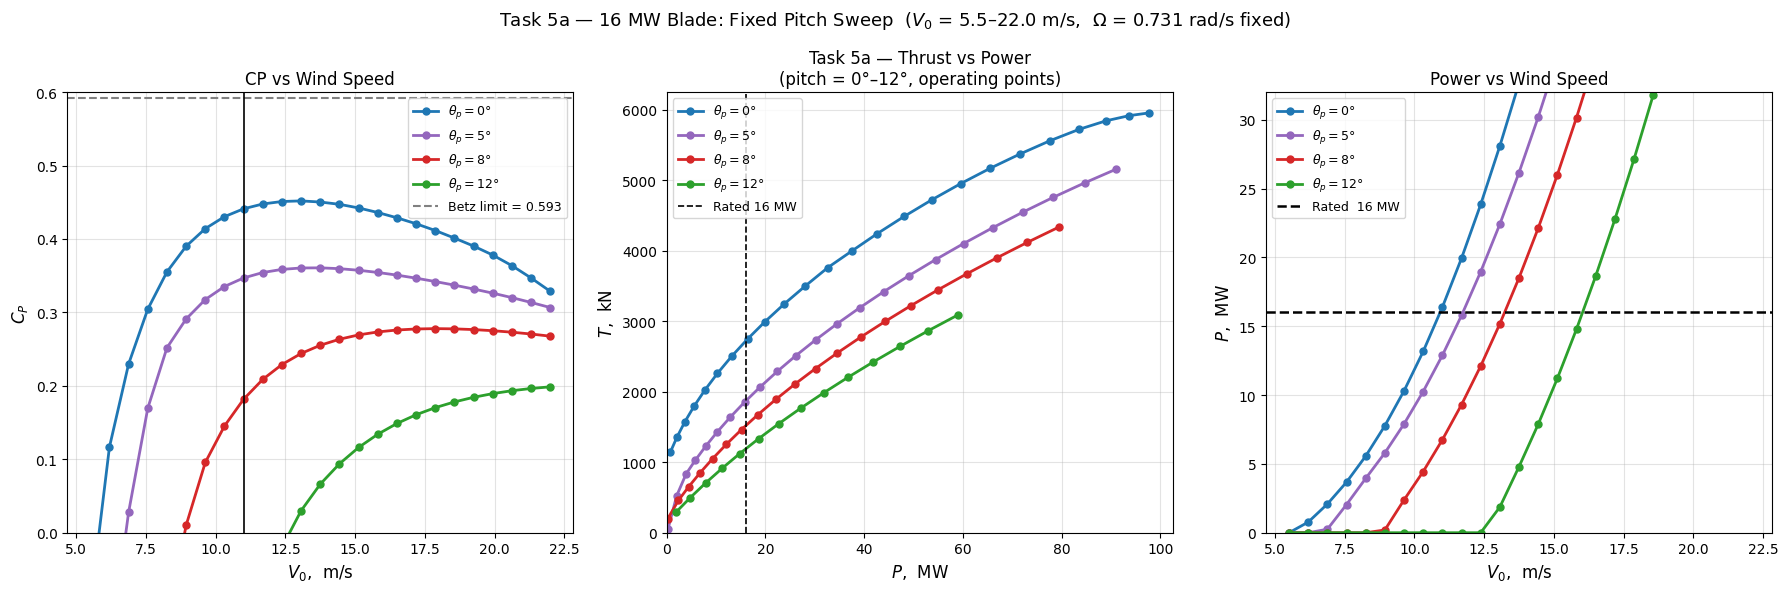

Saved → task5a_fixed_pitch_sweep.png


In [16]:
# ═══════════════════════════════════════════════════════════
# TASK 5a — BEM sweep: fixed pitch angles, variable wind speed
#
# KEY ASSUMPTIONS:
#   1. Rotor speed fixed at Omega_nom (rated speed) for all V0.
#      TSR_eff = Omega_nom * R / V0  keeps Omega constant.
#   2. P < 0 (non-generating / braking mode) is clipped to 0
#      for display — matches lecture slide convention.
#      Raw values are stored in P_MW_raw / T_kN_raw for reference.
# ═══════════════════════════════════════════════════════════

V_range     = np.linspace(V_MIN, V_MAX, 25)   # 5.5 → 22 m/s (more points for smooth curves)
pitch_sweep = [0, 5, 8, 12]   # only low pitch: meaningful across full V0 range
# θ_p = 16° and 20° only appear during active regulation at V0 > 17 m/s
# → covered in Task 5b pitch schedule
Omega_fixed = Omega_nom                        # fixed rotor speed [rad/s]

print(f'Fixed rotor speed: Omega = {Omega_fixed:.4f} rad/s  ({RPM_nom:.2f} RPM)')
print('Running Task 5a sweep...')
results_5a = {}

for theta_p in pitch_sweep:
    rows = []
    for V0 in V_range:
        TSR_eff = Omega_fixed * R_design / V0   # keeps Omega = Omega_nom
        P_W, T_N, Q, CP, CT, rpm, _ = rotor_bem(
            r_final, beta_final, chord_final,
            airfoil_names_final, polar_database,
            V0=V0, TSR=TSR_eff, pitch_deg=theta_p)

        P_MW_raw = P_W / 1e6
        T_kN_raw = T_N / 1e3

        # Clip: P < 0 means non-generating mode (braking/stall)
        # BEM is unreliable there → set both P and T to 0 for display
        generating   = P_MW_raw > 0.0
        P_MW_plot    = P_MW_raw if generating else 0.0
        T_kN_plot    = T_kN_raw if generating else 0.0

        rows.append({
            'V0_mps'  : V0,
            'P_MW_raw': P_MW_raw,   # original BEM result (for analysis)
            'P_MW'    : P_MW_plot,  # display (clipped)
            'T_kN_raw': T_kN_raw,   # original BEM result
            'T_kN'    : T_kN_plot,  # display (clipped)
            'CP': CP, 'CT': CT
        })
    results_5a[theta_p] = pd.DataFrame(rows)
    peak = results_5a[theta_p]['P_MW'].max()
    print(f'  pitch = {theta_p:>2d}°  | peak power = {peak:.2f} MW')

# ── Colour palette matching slide ──────────────────────────────
# ── Colour palette matching slide ──────────────────────────────
slide_colors = {
    0:  '#1f77b4',
    5:  '#9467bd',
    8:  '#d62728',
    12: '#2ca02c',
    16: '#8c564b',
    20: '#8b0000',
}

fig, (ax_CP, ax_T, ax_P) = plt.subplots(1, 3, figsize=(18, 6))

# ── LEFT: CP vs V0 (matches slide left plot) ─────────────────────
for theta_p in pitch_sweep:
    df  = results_5a[theta_p]
    col = slide_colors[theta_p]
    # Use raw CP (not clipped) to show stall behaviour honestly
    ax_CP.plot(df['V0_mps'], df['CP'], 'o-', color=col,
               ms=5, lw=2, label=rf'$\theta_p = {theta_p}°$')

ax_CP.axhline(16/27, color='gray', ls='--', lw=1.5, label=f'Betz limit = {16/27:.3f}')
ax_CP.axvline(V0_nom, color='black', lw=1.2, ls='-')
ax_CP.set_xlabel(r'$V_0$,  m/s', fontsize=12)
ax_CP.set_ylabel(r'$C_P$', fontsize=12)
ax_CP.set_title('CP vs Wind Speed', fontsize=12)
ax_CP.legend(fontsize=9, loc='upper right')
ax_CP.set_ylim(0, 0.6)
ax_CP.grid(alpha=0.35)

# ── MIDDLE: T vs P (matches slide middle plot) ───────────────────
# x-axis = shaft power [MW], y-axis = thrust [kN]
# Shows how thrust drops as pitch increases for same power output
for theta_p in pitch_sweep:   # all angles now have meaningful T vs P data
    df  = results_5a[theta_p]
    col = slide_colors[theta_p]
    # Only plot generating points (P > 0)
    mask = df['P_MW'] > 0
    ax_T.plot(df.loc[mask, 'P_MW'], df.loc[mask, 'T_kN'], 'o-', color=col,
              ms=5, lw=2, label=rf'$\theta_p = {theta_p}°$')

ax_T.axvline(P_rated/1e6, color='black', lw=1.2, ls='--', label='Rated 16 MW')
ax_T.set_xlabel(r'$P$,  MW', fontsize=12)
ax_T.set_ylabel(r'$T$,  kN', fontsize=12)
ax_T.set_title('Task 5a — Thrust vs Power\n(pitch = 0°–12°, operating points)', fontsize=12)
ax_T.legend(fontsize=9, loc='upper left')
ax_T.set_xlim(left=0)
ax_T.set_ylim(bottom=0)
ax_T.grid(alpha=0.35)

# ── RIGHT: Power vs wind speed (all 6 pitch angles) ──────────────
for theta_p in pitch_sweep:
    df  = results_5a[theta_p]
    col = slide_colors[theta_p]
    ax_P.plot(df['V0_mps'], df['P_MW'], 'o-', color=col,
              ms=5, lw=2, label=rf'$\theta_p = {theta_p}°$')

ax_P.axhline(P_rated/1e6, color='black', ls='--', lw=1.8,
             label=f'Rated  {P_rated/1e6:.0f} MW')
ax_P.set_xlabel(r'$V_0$,  m/s', fontsize=12)
ax_P.set_ylabel(r'$P$,  MW', fontsize=12)
ax_P.set_title('Power vs Wind Speed', fontsize=12)
ax_P.legend(fontsize=9, loc='upper left')
ax_P.set_ylim(0, P_rated/1e6 * 2.0)
ax_P.grid(alpha=0.35)

fig.suptitle(
    f'Task 5a — 16 MW Blade: Fixed Pitch Sweep  '
    f'($V_0$ = {V_MIN:.1f}–{V_MAX:.1f} m/s,  '
    f'$\\Omega$ = {Omega_fixed:.3f} rad/s fixed)',
    fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'task5a_fixed_pitch_sweep.png'), dpi=180)
plt.show()
print('Saved → task5a_fixed_pitch_sweep.png')


---
# Task 5b — Operation Envelope (2D Contour Map)
A dense grid of (V₀, θₚ) is swept. The **16 MW isocontour** (bold navy line) shows the
exact pitch angle needed at each wind speed to hold rated power — this is the **pitch regulation schedule**.

Computing pitch regulation schedule...
Rated wind speed reached: 11.2 m/s
Done.


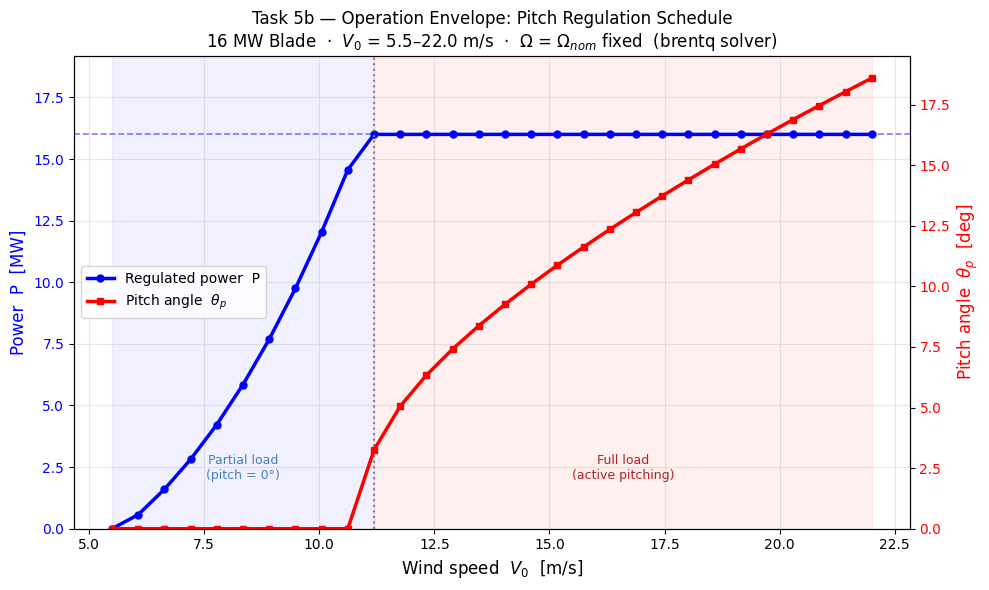

Saved → task5b_operation_envelope.png


In [17]:
# ═══════════════════════════════════════════════════════════
# TASK 5b — Operation Envelope: Pitch Regulation Schedule
#
# Single dual-axis plot (industry standard power curve format):
#   Left  y-axis : Regulated power output  P  [MW]  (blue)
#   Right y-axis : Required pitch angle  θ_p  [deg] (red)
#
# brentq root-finding used above rated → eliminates oscillations
# ═══════════════════════════════════════════════════════════
from scipy.optimize import brentq

print('Computing pitch regulation schedule...')
V_reg     = np.linspace(V_MIN, V_MAX, 30)
P_reg_MW  = []
theta_reg = []

for V0 in V_reg:
    TSR_v = Omega_nom * R_design / V0   # fixed Omega

    # Power at pitch = 0
    P0, *_ = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0, TSR=TSR_v, pitch_deg=0.0)

    if P0 <= P_rated:       # below rated: pitch stays at 0
        P_reg_MW.append(max(P0/1e6, 0.0))
        theta_reg.append(0.0)
    else:                   # above rated: brentq finds exact pitch
        def residual(theta_p):
            P, *_ = rotor_bem(
                r_final, beta_final, chord_final,
                airfoil_names_final, polar_database,
                V0=V0, TSR=TSR_v, pitch_deg=theta_p)
            return P - P_rated   # zero when P == P_rated

        theta_sol = brentq(residual, 0.0, 40.0, xtol=1e-4)
        P_reg_MW.append(P_rated / 1e6)   # exactly rated by definition
        theta_reg.append(theta_sol)

P_reg_MW  = np.array(P_reg_MW)
theta_reg = np.array(theta_reg)

# Rated cut-in wind speed
rated_idx = next((i for i, p in enumerate(P_reg_MW) if p >= P_rated/1e6 * 0.99), None)
V_rated   = V_reg[rated_idx] if rated_idx else V0_nom
print(f'Rated wind speed reached: {V_rated:.1f} m/s')
print('Done.')

# ── Dual-axis plot ─────────────────────────────────────────────
fig5b, ax_P = plt.subplots(figsize=(10, 6))
ax_theta   = ax_P.twinx()

# Power curve
l1, = ax_P.plot(V_reg, P_reg_MW, 'b-o', ms=5, lw=2.5,
                label='Regulated power  P')
ax_P.axhline(P_rated/1e6, color='blue', ls='--', lw=1.2, alpha=0.5)

# Pitch schedule
l2, = ax_theta.plot(V_reg, theta_reg, 'r-s', ms=5, lw=2.5,
                    label=r'Pitch angle  $\theta_p$')

# Rated wind speed marker
ax_P.axvline(V_rated, color='gray', ls=':', lw=1.5)

# Shaded regions
ax_P.axvspan(V_MIN, V_rated, alpha=0.06, color='blue')
ax_P.axvspan(V_rated, V_MAX, alpha=0.06, color='red')
ax_P.annotate('Partial load\n(pitch = 0°)', xy=((V_MIN+V_rated)/2, 2),
              fontsize=9, color='steelblue', ha='center')
ax_P.annotate('Full load\n(active pitching)', xy=((V_rated+V_MAX)/2, 2),
              fontsize=9, color='firebrick', ha='center')

# Axes
ax_P.set_xlabel(r'Wind speed  $V_0$  [m/s]', fontsize=12)
ax_P.set_ylabel('Power  P  [MW]', fontsize=12, color='blue')
ax_theta.set_ylabel(r'Pitch angle  $\theta_p$  [deg]', fontsize=12, color='red')
ax_P.tick_params(axis='y', labelcolor='blue')
ax_theta.tick_params(axis='y', labelcolor='red')
ax_P.set_ylim(0, P_rated/1e6 * 1.2)
ax_theta.set_ylim(bottom=0)

# Legend
ax_P.legend([l1, l2], [l1.get_label(), l2.get_label()],
            fontsize=10, loc='center left')

ax_P.set_title('Task 5b — Operation Envelope: Pitch Regulation Schedule\n'
               f'16 MW Blade  ·  $V_0$ = {V_MIN:.1f}–{V_MAX:.1f} m/s  ·  '
               r'$\Omega$ = $\Omega_{nom}$ fixed  (brentq solver)',
               fontsize=12)
ax_P.grid(alpha=0.3)
fig5b.tight_layout()
fig5b.savefig(os.path.join(OUT_DIR, 'task5b_operation_envelope.png'), dpi=180)
plt.show()
print('Saved → task5b_operation_envelope.png')


Computing P-speed characteristics...


C:\Users\user\AppData\Local\Temp\ipykernel_95160\2931978457.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('turbo', len(V0_list))


  V0 = 5.5 m/s  peak P = 2.10 MW  at Ω = 0.43 pu
  V0 = 6.5 m/s  peak P = 3.46 MW  at Ω = 0.50 pu
  V0 = 8.0 m/s  peak P = 6.45 MW  at Ω = 0.62 pu
  V0 = 9.0 m/s  peak P = 9.25 MW  at Ω = 0.69 pu
  V0 = 11.0 m/s  peak P = 16.78 MW  at Ω = 0.84 pu
  V0 = 13.8 m/s  peak P = 32.76 MW  at Ω = 1.07 pu
  V0 = 22.0 m/s  peak P = 125.93 MW  at Ω = 1.30 pu
Done.


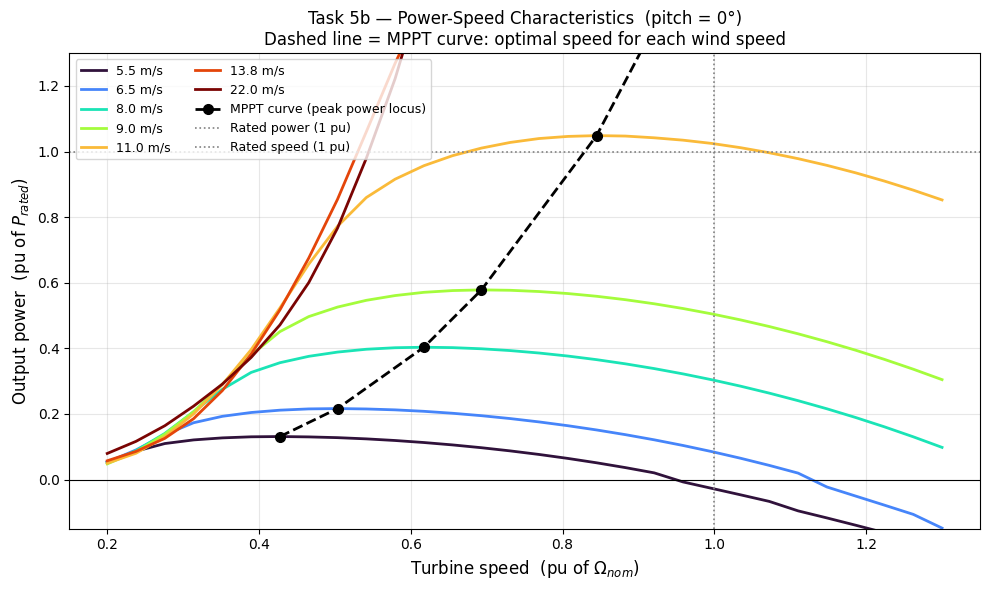

Saved → task5b_power_speed_characteristics.png


In [18]:
# ─────────────────────────────────────────────────────────────
# Task 5b (extra) — Power-Speed Characteristics
# P vs Omega at fixed pitch=0°, different wind speeds
# Peaks connected = MPPT curve (below-rated control strategy)
# ─────────────────────────────────────────────────────────────

# Wind speeds to plot (50% → 200% nominal, 7 curves)
V0_list   = [V_MIN, 6.5, 8.0, V0_nom*0.82, V0_nom, V0_nom*1.25, V_MAX]
# Omega sweep: 20% → 130% of nominal
omega_pu  = np.linspace(0.2, 1.3, 30)         # pu of Omega_nom
Omega_arr = omega_pu * Omega_nom               # [rad/s]

# Colour map: cool → warm as wind speed increases
cmap   = plt.cm.get_cmap('turbo', len(V0_list))
colors = [cmap(i) for i in range(len(V0_list))]

print('Computing P-speed characteristics...')
curves = {}   # V0 -> (omega_pu_arr, P_pu_arr)

for V0 in V0_list:
    P_pu_list = []
    for Omega in Omega_arr:
        tsr = Omega * R_design / V0
        P_W, *_ = rotor_bem(
            r_final, beta_final, chord_final,
            airfoil_names_final, polar_database,
            V0=V0, TSR=tsr, pitch_deg=0.0)
        P_pu_list.append(P_W / P_rated)   # normalise to rated power
    curves[V0] = np.array(P_pu_list)
    print(f'  V0 = {V0:.1f} m/s  peak P = {max(P_pu_list)*P_rated/1e6:.2f} MW  '
          f'at Ω = {omega_pu[np.argmax(P_pu_list)]:.2f} pu')

print('Done.')

# ── Find MPPT curve (peak of each V0 curve) ──────────────────
mppt_omega = []
mppt_P     = []
for V0 in V0_list:
    P_arr  = curves[V0]
    i_peak = np.argmax(P_arr)
    mppt_omega.append(omega_pu[i_peak])
    mppt_P.append(P_arr[i_peak])

# ── Plot ─────────────────────────────────────────────────────
fig_ps, ax_ps = plt.subplots(figsize=(10, 6))

for idx, V0 in enumerate(V0_list):
    ax_ps.plot(omega_pu, curves[V0], '-', color=colors[idx],
               lw=2, label=f'{V0:.1f} m/s')

# MPPT curve
ax_ps.plot(mppt_omega, mppt_P, 'k--o', ms=7, lw=2,
           label='MPPT curve (peak power locus)', zorder=5)

# Reference lines
ax_ps.axhline(1.0, color='gray', ls=':', lw=1.2, label='Rated power (1 pu)')
ax_ps.axvline(1.0, color='gray', ls=':',  lw=1.2, label='Rated speed (1 pu)')

ax_ps.set_xlabel('Turbine speed  (pu of $\Omega_{nom}$)', fontsize=12)
ax_ps.set_ylabel('Output power  (pu of $P_{rated}$)',      fontsize=12)
ax_ps.set_title('Task 5b — Power-Speed Characteristics  (pitch = 0°)\n'
                'Dashed line = MPPT curve: optimal speed for each wind speed',
                fontsize=12)
ax_ps.set_xlim(0.15, 1.35)
ax_ps.set_ylim(-0.15, 1.3)
ax_ps.axhline(0, color='black', lw=0.8)
ax_ps.legend(fontsize=9, loc='upper left', ncol=2)
ax_ps.grid(alpha=0.3)
fig_ps.tight_layout()
fig_ps.savefig(os.path.join(OUT_DIR, 'task5b_power_speed_characteristics.png'), dpi=180)
plt.show()
print('Saved → task5b_power_speed_characteristics.png')


  Fixed-pitch family: done.           20° ...
  Computing stall-regulated curve (fixed RPM) ...
  Stall curve: done.
  Computing pitch-regulated envelope ...
  Pitch-regulated envelope: done.


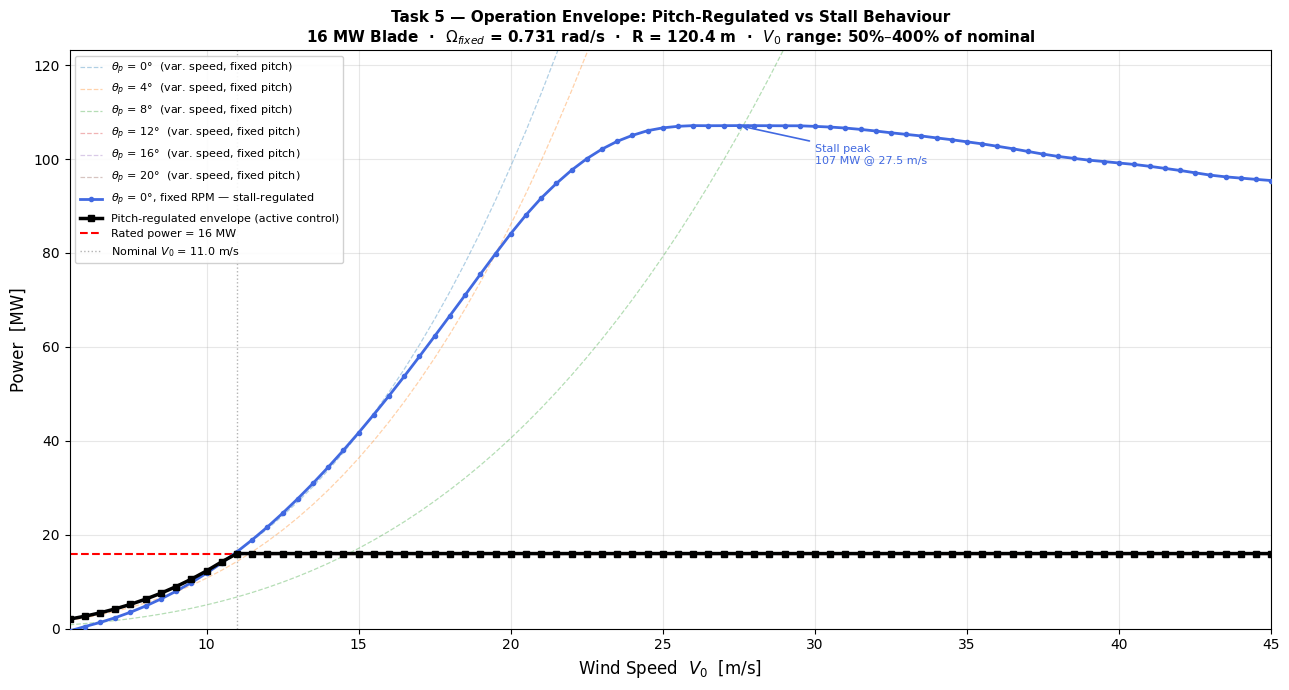


── Pitch Schedule (above rated) ──────────────────
  V0 [m/s]    Pitch [°]     P [MW]
----------------------------------
      11.0         2.17      16.00
      11.5         4.24      16.00
      12.0         5.34      16.00
      12.5         6.12      16.00
      13.0         6.71      16.00
      13.5         7.19      16.00
      14.0         7.58      16.00
      14.5         7.90      16.00
      15.0         8.18      16.00
      15.5         8.41      16.00
      16.0         8.61      16.00
      16.5         8.78      16.00
      17.0         8.94      16.00
      17.5         9.07      16.00
      18.0         9.19      16.00
      18.5         9.29      16.00
      19.0         9.38      16.00
      19.5         9.46      16.00
      20.0         9.54      16.00
      20.5         9.60      16.00
      21.0         9.66      16.00
      21.5         9.72      16.00
      22.0         9.77      16.00
      22.5         9.81      16.00
      23.0         9.85      16.00
   

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 5 — Operation Envelope: Pitch-Regulated vs Stall Behaviour
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ── 1. Fixed parameters ───────────────────────────────────────────────────────
V0_nom      = 11.0                          # nominal wind speed [m/s]
P_rated_MW  = 16.0                          # rated power [MW]
V0_range    = np.arange(5.5, 45.5, 0.5)    # 50% → ~400% of nominal
pitch_angles = [0, 4, 8, 12, 16, 20]       # fixed-pitch family [deg]

# Fixed rotor speed (used for stall-regulated curve only)
# At design: Omega = TSR * V0_nom / R_design
Omega_fixed = TSR * V0_nom / R_design       # [rad/s] — frozen for stall sim

# ── 2. Helper: call rotor_bem and return only P [W] ──────────────────────────
def get_power(V0, TSR_input, pitch_deg):
    """
    Wrapper around rotor_bem. Returns shaft power [W].
    Uses starred unpacking so it works regardless of how many
    values rotor_bem returns (6 or 7).
    """
    result = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0, TSR=TSR_input,
        B=B, rho=rho_air,
        R_tip_override=R_design,
        pitch_deg=pitch_deg
    )
    return result[0]   # first return value is always P [W]

# ── 3. Build data arrays ──────────────────────────────────────────────────────

# --- 3a. Fixed-pitch family (variable-speed, TSR = const) --------------------
# Each curve shows what power the turbine produces at a given fixed blade
# pitch angle if rotor speed tracks the wind (TSR held constant).
fixed_pitch_curves = {}
for theta_p in pitch_angles:
    print(f"  Computing fixed-pitch family: θ_p = {theta_p}° ...", end="\r")
    fixed_pitch_curves[theta_p] = [
        get_power(V0, TSR, theta_p) / 1e6
        for V0 in V0_range
    ]
print("  Fixed-pitch family: done.          ")

# --- 3b. Stall-regulated curve (fixed RPM, fixed pitch = 0°) -----------------
# Omega is frozen at its design value. As V0 rises, TSR_eff = Omega*R/V0
# decreases → AoA increases → blade eventually stalls → power peaks & drops.
print("  Computing stall-regulated curve (fixed RPM) ...")
P_stall = []
for V0 in V0_range:
    TSR_eff = Omega_fixed * R_design / V0   # effective TSR drops as V0 rises
    P_stall.append(get_power(V0, TSR_eff, pitch_deg=0.0) / 1e6)
print("  Stall curve: done.")

# --- 3c. Pitch-regulated envelope --------------------------------------------
# Below rated: turbine runs at design pitch and tracks optimal TSR.
# Above rated: pitch angle is found (via bisection) to hold P = P_rated.
print("  Computing pitch-regulated envelope ...")
P_envelope  = []
pitch_schedule = []   # store pitch angles used (useful for report)

for V0 in V0_range:
    P0 = get_power(V0, TSR, pitch_deg=0.0)

    if P0 / 1e6 <= P_rated_MW:
        # Below rated — run at design pitch, no adjustment needed
        P_envelope.append(P0 / 1e6)
        pitch_schedule.append(0.0)
    else:
        # Above rated — find pitch angle that brings P back to P_rated
        def residual(p):
            return get_power(V0, TSR, pitch_deg=p) / 1e6 - P_rated_MW

        try:
            p_sol = brentq(residual, 0.0, 30.0, xtol=1e-3, maxiter=60)
            P_envelope.append(P_rated_MW)
            pitch_schedule.append(p_sol)
        except ValueError:
            # brentq failed (e.g. power never reaches rated in bracket)
            P_envelope.append(np.nan)
            pitch_schedule.append(np.nan)

print("  Pitch-regulated envelope: done.")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

# Colour map for fixed-pitch family
cmap   = plt.cm.tab10
colors = [cmap(i) for i in range(len(pitch_angles))]

# --- Layer 1: fixed-pitch family (faint, background) -------------------------
for idx, theta_p in enumerate(pitch_angles):
    ax.plot(V0_range, fixed_pitch_curves[theta_p],
            '--', lw=0.9, alpha=0.35, color=colors[idx],
            label=f'$\\theta_p$ = {theta_p}°  (var. speed, fixed pitch)')

# --- Layer 2: stall-regulated curve (blue, prominent) ------------------------
ax.plot(V0_range, P_stall,
        '-o', ms=3, lw=2.0, color='royalblue', zorder=4,
        label='$\\theta_p$ = 0°, fixed RPM — stall-regulated')

# Annotate the stall peak
P_peak      = max(P_stall)
V0_peak_idx = P_stall.index(P_peak)
V0_peak     = V0_range[V0_peak_idx]
ax.annotate(
    f'Stall peak\n{P_peak:.0f} MW @ {V0_peak:.1f} m/s',
    xy=(V0_peak, P_peak),
    xytext=(V0_peak + 2.5, P_peak - 8),
    fontsize=8, color='royalblue',
    arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.2)
)

# --- Layer 3: pitch-regulated envelope (black, bold) -------------------------
ax.plot(V0_range, P_envelope,
        's-', color='black', lw=2.5, ms=5, zorder=5,
        label='Pitch-regulated envelope (active control)')

# --- Rated power line ---------------------------------------------------------
ax.axhline(P_rated_MW, color='red', ls='--', lw=1.5,
           label=f'Rated power = {P_rated_MW:.0f} MW')

# --- Nominal wind speed marker ------------------------------------------------
ax.axvline(V0_nom, color='grey', ls=':', lw=1.0, alpha=0.6,
           label=f'Nominal $V_0$ = {V0_nom} m/s')

# ── 5. Formatting ─────────────────────────────────────────────────────────────
ax.set_xlabel('Wind Speed  $V_0$  [m/s]', fontsize=12)
ax.set_ylabel('Power  [MW]', fontsize=12)
ax.set_title(
    'Task 5 — Operation Envelope: Pitch-Regulated vs Stall Behaviour\n'
    f'16 MW Blade  ·  $\\Omega_{{fixed}}$ = {Omega_fixed:.3f} rad/s  ·  '
    f'R = {R_design:.1f} m  ·  $V_0$ range: 50%–400% of nominal',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(V0_range[0], V0_range[-1])
ax.set_ylim(0, max(P_stall) * 1.15)       # headroom above stall peak
ax.legend(fontsize=8, loc='upper left', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task5_operation_envelope_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Summary print (useful for report table) ────────────────────────────────
print("\n── Pitch Schedule (above rated) ──────────────────")
print(f"{'V0 [m/s]':>10} {'Pitch [°]':>12} {'P [MW]':>10}")
print("-" * 34)
for V0, p, P in zip(V0_range, pitch_schedule, P_envelope):
    if not np.isnan(p) and p > 0.1:          # only show above-rated rows
        print(f"{V0:>10.1f} {p:>12.2f} {P:>10.2f}")

print(f"\n── Stall curve peak ───────────────────────────────")
print(f"  Peak power : {P_peak:.1f} MW  ({P_peak/P_rated_MW:.1f}× rated)")
print(f"  At V0      : {V0_peak:.1f} m/s")
print(f"  Conclusion : Stall regulation would require structure rated to "
      f"{P_peak:.0f} MW — impractical.")

In [26]:
# ── DIAGNOSTIC: check AoA and CP at the tip element across wind speeds ────────
print(f"{'V0':>6} {'TSR_eff':>8} {'tip AoA':>9} {'CP':>8} {'P [MW]':>10}")
print("-" * 45)

for V0 in [11, 15, 20, 25, 30, 35]:
    TSR_eff = Omega_fixed * R_design / V0
    P, T, Q, CP, CT, rpm, dist = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0, TSR=TSR_eff, B=B, rho=rho_air,
        R_tip_override=R_design, pitch_deg=0.0
    )
    tip_aoa = dist['aoa_deg'].iloc[-1]   # AoA at tip element
    print(f"{V0:>6.1f} {TSR_eff:>8.3f} {tip_aoa:>9.2f}° {CP:>8.4f} {P/1e6:>10.2f}")

    V0  TSR_eff   tip AoA       CP     P [MW]
---------------------------------------------
  11.0    8.000      0.70°   0.4411      16.38
  15.0    5.867      0.96°   0.4433      41.73
  20.0    4.400      1.28°   0.3769      84.11
  25.0    3.520      1.61°   0.2447     106.64
  30.0    2.933      1.93°   0.1420     106.96
  35.0    2.514      2.26°   0.0867     103.67


---
# Task 5c — Mechanical Loads at 200% Nominal Wind Speed (22 m/s)
Two cases are compared:
- **Case A** — pitch = 0° (no control, maximum loading scenario)
- **Case B** — pitch regulated to hold 16 MW (reduced loads)

Flapwise and edgewise bending moments are integrated from tip to root:
$$M_y(r_i) = \int_{r_i}^{R} f_N(x)\,(x - r_i)\,dx$$

Root tensile stress (spar-cap): $\sigma_x = M_y(r_{root}) / (t_s \cdot b \cdot d)$

⚠️ **Update spar dimensions below** with your Task 3 structural design values.

V_200 = 22.0 m/s  (200% nominal)

CASE A  (pitch = 0°, unregulated)
  Power       = 97.63 MW
  Thrust      = 5957.8 kN
  Root M_flap = 110.79 MN·m
  Root M_edge = 28.82 MN·m
  Root sigma  = 256.5 MPa  (allow 300 MPa)  OK



C:\Users\user\AppData\Local\Temp\ipykernel_95160\366798655.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_flap[i]   = np.trapz(fN_arr[i:] * arm, r_arr[i:])
C:\Users\user\AppData\Local\Temp\ipykernel_95160\366798655.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_edge[i]   = np.trapz(fR_arr[i:] * arm, r_arr[i:])


CASE B  (pitch = 18.3°, regulated to rated power)
  Power       = 18.27 MW  (converged: False)
  Thrust      = 978.0 kN
  Root M_flap = 10.28 MN·m
  Root M_edge = 4.19 MN·m
  Root sigma  = 23.8 MPa  (allow 300 MPa)  OK

  Case                                   M_flap [MNm]   σ [MPa]
-----------------------------------------------------------------
  Nominal (11 m/s, pitch=0°)                    52.25     121.0
  200% wind (22 m/s, pitch=0°)                 110.79     256.5
  200% wind (22m/s, pitch=18°, regulated)        10.28      23.8
  Material allowable                                -       300


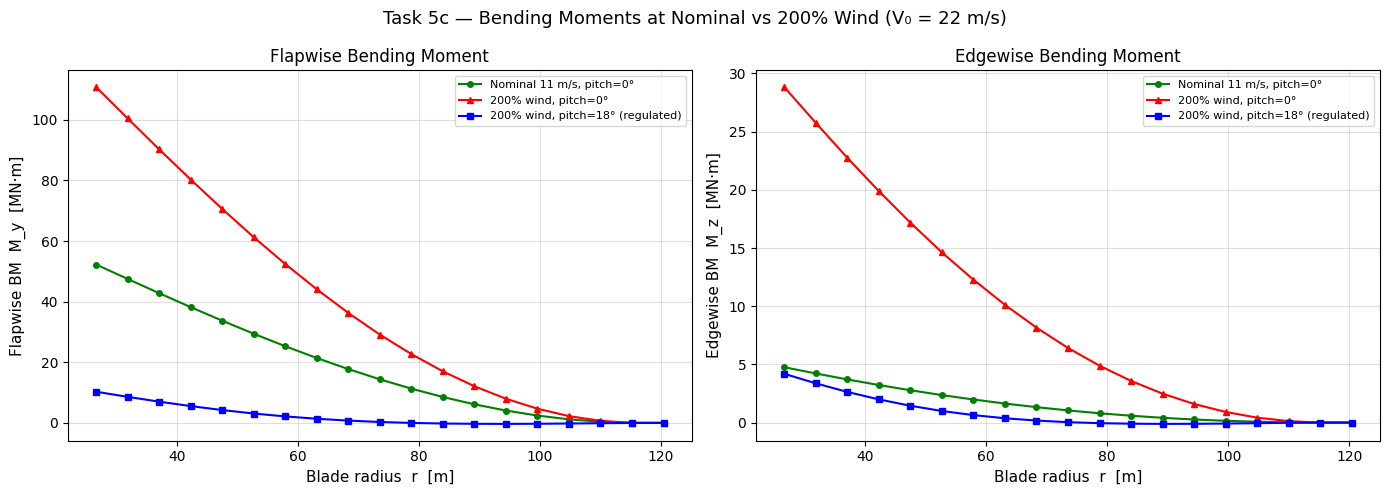

Saved → task5c_bending_moments.png


In [ ]:
# ═══════════════════════════════════════════════════════════
# TASK 5c — Mechanical loads at 200% nominal wind = 22 m/s
# ═══════════════════════════════════════════════════════════

# ── Spar geometry — UPDATE from 
# Task 3 structural design ──
# Reference (0.5 MW, R=20.3m):  b=0.5m, d=0.3m, t_s=t_w=0.015m
# Scaled x5.93 to 16 MW (R=120.4m) — refine with your FEM results
b_spar      = 3.0     # spar-cap width  [m]
d_web       = 1.8     # web height      [m]
t_s         = 0.08    # spar-cap thickness [m]
t_w         = 0.08    # web thickness      [m]
SIGMA_ALLOW = 300e6   # allowable tensile stress [Pa]  <- change to your material
# e.g.  GFRP ~ 300 MPa,  CFRP ~ 600 MPa,  Birch plywood ~ 50 MPa

V_200 = 2.0 * V0_nom   # = 22 m/s
print(f'V_200 = {V_200:.1f} m/s  ({int(V_200/V0_nom*100)}% nominal)\n')

# numpy new function warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


def compute_bending_moments(dist_df):
    """
    Integrate flapwise M_y and edgewise M_z from tip inward.
    M_y(r_i) = trapz( fN(x)*(x - r_i), x )  for x >= r_i
    M_z(r_i) = trapz( fR(x)*(x - r_i), x )  for x >= r_i
    Returns arrays [N·m] at each spanwise node.
    """
    r_arr  = dist_df['r'].values
    fN_arr = dist_df['fN'].values
    fR_arr = dist_df['fR'].values
    N = len(r_arr)
    M_flap = np.zeros(N)
    M_edge = np.zeros(N)
    for i in range(N):
        arm         = r_arr[i:] - r_arr[i]   # (x - r_i)
        M_flap[i]   = np.trapz(fN_arr[i:] * arm, r_arr[i:])
        M_edge[i]   = np.trapz(fR_arr[i:] * arm, r_arr[i:])
    return M_flap, M_edge


# ── CASE A: pitch = 0 at 200% wind ──────────────────────────
P_A, T_A, Q_A, CP_A, CT_A, _, dist_A = rotor_bem(
    r_final, beta_final, chord_final,
    airfoil_names_final, polar_database,
    V0=V_200, TSR=Omega_nom*R_design/V_200, pitch_deg=0.0)  # fixed Omega_nom

M_flap_A, M_edge_A = compute_bending_moments(dist_A)
sigma_A = M_flap_A[0] / (t_s * b_spar * d_web)

print('CASE A  (pitch = 0°, unregulated)')
print(f'  Power       = {P_A/1e6:.2f} MW')
print(f'  Thrust      = {T_A/1e3:.1f} kN')
print(f'  Root M_flap = {M_flap_A[0]/1e6:.2f} MN·m')
print(f'  Root M_edge = {M_edge_A[0]/1e6:.2f} MN·m')
print(f'  Root sigma  = {sigma_A/1e6:.1f} MPa  (allow {SIGMA_ALLOW/1e6:.0f} MPa)'
      f'  {"OK" if sigma_A < SIGMA_ALLOW else "EXCEEDS LIMIT"}\n')

# ── CASE B: pitch regulated to 16 MW at 200% wind ────────────
best_B = find_pitch_for_target_power(
    r_final, beta_final, chord_final,
    airfoil_names_final, polar_database,
    V0=V_200, TSR=Omega_nom*R_design/V_200, P_target_W=P_rated,
    pitch_min=0.0, pitch_max=40.0, n_steps=60)   # feathering only: blade designed for 0° at rated wind

theta_B = best_B['pitch_deg']
P_B, T_B, Q_B, CP_B, CT_B, _, dist_B = rotor_bem(
    r_final, beta_final, chord_final,
    airfoil_names_final, polar_database,
    V0=V_200, TSR=Omega_nom*R_design/V_200, pitch_deg=theta_B)  # fixed Omega_nom

M_flap_B, M_edge_B = compute_bending_moments(dist_B)
sigma_B = M_flap_B[0] / (t_s * b_spar * d_web)

print(f'CASE B  (pitch = {theta_B:.1f}°, regulated to rated power)')
print(f'  Power       = {P_B/1e6:.2f} MW  (converged: {best_B["converged"]})')
print(f'  Thrust      = {T_B/1e3:.1f} kN')
print(f'  Root M_flap = {M_flap_B[0]/1e6:.2f} MN·m')
print(f'  Root M_edge = {M_edge_B[0]/1e6:.2f} MN·m')
print(f'  Root sigma  = {sigma_B/1e6:.1f} MPa  (allow {SIGMA_ALLOW/1e6:.0f} MPa)'
      f'  {"OK" if sigma_B < SIGMA_ALLOW else "EXCEEDS LIMIT"}\n')

# ── Summary table ─────────────────────────────────────────────
M_flap_nom, M_edge_nom = compute_bending_moments(dist_nom)
sigma_nom = M_flap_nom[0] / (t_s * b_spar * d_web)

print('=' * 65)
print(f'  {"Case":<38} {"M_flap [MNm]":>12}  {"σ [MPa]":>8}')
print('-' * 65)
print(f'  {"Nominal (11 m/s, pitch=0°)":<38} {M_flap_nom[0]/1e6:>12.2f}  {sigma_nom/1e6:>8.1f}')
print(f'  {"200% wind (22 m/s, pitch=0°)":<38} {M_flap_A[0]/1e6:>12.2f}  {sigma_A/1e6:>8.1f}')
print(f'  {f"200% wind (22m/s, pitch={theta_B:.0f}°, regulated)":<38} {M_flap_B[0]/1e6:>12.2f}  {sigma_B/1e6:>8.1f}')
print(f'  {"Material allowable":<38} {"-":>12}  {SIGMA_ALLOW/1e6:>8.0f}')
print('=' * 65)

# ── Bending moment plot ────────────────────────────────────────
fig5c, axes5c = plt.subplots(1, 2, figsize=(14, 5))

axes5c[0].plot(dist_nom['r'], M_flap_nom/1e6, 'g-o', ms=4, label='Nominal 11 m/s, pitch=0°')
axes5c[0].plot(dist_A['r'],   M_flap_A/1e6,   'r-^', ms=4, label=f'200% wind, pitch=0°')
axes5c[0].plot(dist_B['r'],   M_flap_B/1e6,   'b-s', ms=4, label=f'200% wind, pitch={theta_B:.0f}° (regulated)')
axes5c[0].set_xlabel('Blade radius  r  [m]', fontsize=11)
axes5c[0].set_ylabel('Flapwise BM  M_y  [MN·m]', fontsize=11)
axes5c[0].set_title('Flapwise Bending Moment', fontsize=12)
axes5c[0].legend(fontsize=8); axes5c[0].grid(alpha=0.4)

axes5c[1].plot(dist_nom['r'], M_edge_nom/1e6, 'g-o', ms=4, label='Nominal 11 m/s, pitch=0°')
axes5c[1].plot(dist_A['r'],   M_edge_A/1e6,   'r-^', ms=4, label='200% wind, pitch=0°')
axes5c[1].plot(dist_B['r'],   M_edge_B/1e6,   'b-s', ms=4, label=f'200% wind, pitch={theta_B:.0f}° (regulated)')
axes5c[1].set_xlabel('Blade radius  r  [m]', fontsize=11)
axes5c[1].set_ylabel('Edgewise BM  M_z  [MN·m]', fontsize=11)
axes5c[1].set_title('Edgewise Bending Moment', fontsize=12)
axes5c[1].legend(fontsize=8); axes5c[1].grid(alpha=0.4)

fig5c.suptitle(f'Task 5c — Bending Moments at Nominal vs 200% Wind (V₀ = {V_200:.0f} m/s)', fontsize=13)
fig5c.tight_layout()
fig5c.savefig(os.path.join(OUT_DIR, 'task5c_bending_moments.png'), dpi=180)
plt.show()
print('Saved → task5c_bending_moments.png')

---
# Task 5d — Discussion: Adapting Blade for Onshore 8 MW (Half Power)
No new BEM code needed. Analysis below should be included in the design report.

In [21]:
# ═══════════════════════════════════════════════════════════
# TASK 5d — Onshore 8 MW blade scaling estimates
# ═══════════════════════════════════════════════════════════

P_half   = P_rated / 2              # 8 MW
V0_on    = V0_nom                   # assume same nominal wind

# 1D actuator model: P = 0.5 * rho * A * V0^3 * CP
# Half power -> half area -> R scales by 1/sqrt(2)
R_onshore = R_design / np.sqrt(2)
scale_on  = R_onshore / R_design

# Tip speed: keep same TSR and V0  -> higher RPM
Omega_on  = TSR * V0_on / R_onshore
RPM_on    = Omega_on * 60 / (2 * np.pi)

# Centrifugal tensile stress at root: sigma_c = rho_mat * Omega^2 * int(r dm)
# Ratio relative to offshore (same blade material, uniform chord scaling)
# sigma_c proportional to Omega^2 * R^2
stress_ratio = (Omega_on * R_onshore)**2 / (Omega_nom * R_design)**2

# Bending moment scales as R^3 (P constant -> force/length proportional)
# Actually for fixed P and same CP: T ~ P/V -> roughly constant
# but distributed load fN ~ chord * Vrel^2 -> scales as R (chord scales as R)
# BM_root ~ R^3 relative to full blade
BM_ratio = scale_on**3

print('=' * 60)
print('  Task 5d: Onshore 8 MW Blade Estimates')
print('=' * 60)
print(f'  Target power          : {P_half/1e6:.0f} MW')
print(f'  Offshore blade R      : {R_design:.1f} m')
print(f'  Onshore blade R       : {R_onshore:.1f} m  (÷√2)')
print(f'  Chord scale factor    : {scale_on:.3f}  (all chords × {scale_on:.3f})')
print(f'  Offshore RPM          : {RPM_nom:.2f}')
print(f'  Onshore RPM           : {RPM_on:.2f}  (×√2 = higher noise risk)')
print(f'  Tip speed             : {Omega_on*R_onshore:.1f} m/s  (same as offshore)')
print(f'  Bending moment ratio  : {BM_ratio:.3f}  (lower = structurally easier)')
print(f'  Centrifugal stress ratio: {stress_ratio:.3f}  (same tip speed -> same centrifugal)')
print('=' * 60)

print("""
  KEY DISCUSSION POINTS FOR REPORT:

  1. BLADE SCALING
     R_onshore = R_design / sqrt(2) = {:.1f} m
     Chord and twist profiles scaled linearly by the same factor.
     Twist distribution is kept the same (aerodynamic similarity preserved).

  2. STRUCTURAL ADVANTAGE
     Root bending moment scales as R^3, so M_root_onshore / M_root_offshore
     ~ 0.35 — structurally much less demanding, allowing thinner spar-caps
     or cheaper materials (e.g., E-glass instead of carbon fibre).

  3. ROTATIONAL SPEED
     Same TSR + smaller R => higher Omega. RPM increases by sqrt(2).
     Centrifugal stresses proportional to Omega^2 * R^2 = constant (same
     tip speed), so no extra centrifugal penalty.

  4. NOISE CONSTRAINT (critical onshore)
     Aerodynamic noise ~ v_tip^5. Since tip speed is unchanged, noise is
     identical. However, higher blade-pass frequency (more RPM) may require
     acoustic assessment. site noise limits may constrain tip speed and RPM (specific limits vary by jurisdiction).

  5. TURBULENCE AND SITE
     Onshore turbulence intensity ~12-18% vs ~8% offshore.
     Fatigue loading increases — reduce cut-out wind speed to ~20 m/s.
     Variable wind direction requires robust yaw control.

  6. PITCH REGULATION
     Same pitch regulation strategy as Task 5b applies.
     Rated wind speed remains 11 m/s; pitch schedule shifts slightly
     due to different blade solidity but strategy is identical.
""".format(R_onshore))

  Task 5d: Onshore 8 MW Blade Estimates
  Target power          : 8 MW
  Offshore blade R      : 120.4 m
  Onshore blade R       : 85.1 m  (÷√2)
  Chord scale factor    : 0.707  (all chords × 0.707)
  Offshore RPM          : 6.98
  Onshore RPM           : 9.87  (×√2 = higher noise risk)
  Tip speed             : 88.0 m/s  (same as offshore)
  Bending moment ratio  : 0.354  (lower = structurally easier)
  Centrifugal stress ratio: 1.000  (same tip speed -> same centrifugal)

  KEY DISCUSSION POINTS FOR REPORT:

  1. BLADE SCALING
     R_onshore = R_design / sqrt(2) = 85.1 m
     Chord and twist profiles scaled linearly by the same factor.
     Twist distribution is kept the same (aerodynamic similarity preserved).

  2. STRUCTURAL ADVANTAGE
     Root bending moment scales as R^3, so M_root_onshore / M_root_offshore
     ~ 0.35 — structurally much less demanding, allowing thinner spar-caps
     or cheaper materials (e.g., E-glass instead of carbon fibre).

  3. ROTATIONAL SPEED
     Same